# Capstone Project - Cards Fraud Detection #
## Fraud Prevention Modelling ##

## 1. Summary ##
The aim is to build an effective and robust Card Fraud Detection Model with real world IEEE dataset provided by Vesta Corporation using the CRISP-DM methodology; a model that:
- utilises engineered features,
- works with class imbalance,
- can be updated in a streamlined way and
- is readily adoptable in a realtime card detection process on a Payment Switch.

This will help us streamline the methodology, steps and resue the process on building a robust model for other cards payment data. The data has been made available freely on Kaggle(a user login is required to downlad the datasets). This data was presented in a data science competition held 7 years ago. The data comes from Vesta's real-world e-commerce transactions and contains a wide range of features from device type to product features.

## 2. Exploratory Data Analysis (EDA) Summary ##

**NOTE:** 

**I have republished the EDA Summary and findings here for context. For thorough analysis see the Jupyter file: cards_fraud_EDA_and_BaselineModel**

**Data structure**
-  I merged train_transaction (590,540 × 394) and train_identity (144,233 × 41) into a 590,540 × 434 training table and similarly merged the test tables.
-  The target isFraud has mean ≈ 0.035, confirming ~3.5% fraud rate (strong class imbalance).

**Core numeric features**
- TransactionAmt is positive, clearly right‑skewed with a heavy tail; the median is ~68.8 and the maximum is ~31,937, indicating a few very large outliers.
- TransactionDT spans a large range and is not a calendar timestamp but an increasing integer that one can convert to approximate days and hours; distributions are broad, as expected.
- Customer‑behaviour count features C1–C8 show extreme skew: medians at 0–1 with occasional large values (thousands), consistent with count‑style features that can be good predictors.

**Categorical / identity hints**
- DeviceType appears in the merged table with non‑trivial missingness and different fraud rates: in your small table desktop has ~6.5% and mobile ~10.2% fraud (on the subset shown), suggesting device type is informative.
- The identity file contributes 41 additional fields (id_01–id_38, DeviceType, DeviceInfo) but many have high missing fractions and need careful treatment.

**Missingness**
- Many identity and V‑features have substantial missingness (often > 50%, some > 90%), while core transaction fields like TransactionAmt, card1, C1–C8 are largely complete.
- This pattern suggests a two‑tier feature set: robust, low‑missing transaction features and sparser identity/V‑features to be either imputed or selectively used.

## 3. Library Imports ##

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import lightgbm as lgb
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.metrics import roc_auc_score, average_precision_score, classification_report, confusion_matrix
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier, IsolationForest
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, average_precision_score, classification_report, confusion_matrix
from sklearn.metrics import (
    roc_curve, precision_recall_curve,
    roc_auc_score, average_precision_score
)

## 4. Load and merge data ##
Goal: Read the CSVs, inspect shapes, and join train_transaction and train_identity on TransactionID

In [2]:
# Set a path if running locally; in Kaggle these files can be found at https://www.kaggle.com/c/ieee-fraud-detection/data
DATA_PATH = "data/ieee-fraud-detection"

train_trans = pd.read_csv(f"{DATA_PATH}/train_transaction.csv")
train_id = pd.read_csv(f"{DATA_PATH}/train_identity.csv")

test_trans = pd.read_csv(f"{DATA_PATH}/test_transaction.csv")
test_id = pd.read_csv(f"{DATA_PATH}/test_identity.csv")

print("Train transaction shape:", train_trans.shape)
print("Train identity shape:", train_id.shape)
print("Test transaction shape:", test_trans.shape)
print("Test identity shape:", test_id.shape)

# Merge train
train = train_trans.merge(train_id, how="left", on="TransactionID")
print("Merged train shape:", train.shape)

# Merge test (for later consistency checks, not used in EDA with target)
test = test_trans.merge(test_id, how="left", on="TransactionID")
print("Merged test shape:", test.shape)

# Inspect columns
train.head()

Train transaction shape: (590540, 394)
Train identity shape: (144233, 41)
Test transaction shape: (506691, 393)
Test identity shape: (141907, 41)
Merged train shape: (590540, 434)
Merged test shape: (506691, 433)


,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,...,id_31,id_32,id_33,id_34,id_35,id_36,id_37,id_38,DeviceType,DeviceInfo
0,2987000,0,86400,68.5,W,13926,NaN,150.0,discover,142.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2987001,0,86401,29.0,W,2755,404.0,150.0,mastercard,102.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2987002,0,86469,59.0,W,4663,490.0,150.0,visa,166.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2987003,0,86499,50.0,W,18132,567.0,150.0,mastercard,117.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2987004,0,86506,50.0,H,4497,514.0,150.0,mastercard,102.0,...,samsung browser 6.2,32.0,2220x1080,match_status:2,T,F,T,T,mobile,SAMSUNG SM-G892A Build/NRD90M


## 5. Data Preprocessing and Feature pipeline design ##
The idea is to:
- Drop clearly unhelpful or extremely sparse features
- Create interpretable time and log-amount features
- Encode categoricals (target counts = frequency) in a simple, leakage-safe way
- Impute numeric and categorical values
- Standardise numeric features for Logistic Regression

### 5.1 Define Feature groups ###

In [3]:
TARGET = 'isFraud'

# Identify dtypes
num_cols = train.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = train.select_dtypes(exclude=[np.number]).columns.tolist()

num_cols = [c for c in num_cols if c != TARGET]

print("Numeric cols:", len(num_cols))
print("Categorical cols:", len(cat_cols))

Numeric cols: 402
Categorical cols: 31


### 5.2 Mark high-missing and ID-like features yo drop ###

In [4]:
missing_train = train.isnull().mean()

# Drop threshold: > 95% missing
high_missing = missing_train[missing_train > 0.95].index.tolist()

# ID-like or non-informative columns
id_like = ['TransactionID']  # extend list if needed

drop_cols = set(high_missing + id_like)

print("High-missing (>95%) features:", len(high_missing))
print("Drop columns (initial):", len(drop_cols))

High-missing (>95%) features: 9
Drop columns (initial): 10


### 5.3 Create engineered features (amount & time & simple risk) ###

In [5]:
def add_basic_features(df):
    df = df.copy()
    # Log amount
    df['log_TransactionAmt'] = np.log1p(df['TransactionAmt'])
    
    # Time features
    df['TransactionDT_days'] = df['TransactionDT'] / (24*60*60)
    df['TransactionDT_day'] = df['TransactionDT_days'].astype(int)
    df['TransactionDT_hour'] = (df['TransactionDT'] // 3600) % 24
    df['is_weekend'] = df['TransactionDT_day'] % 7 >= 5
    
    return df

train_fe = add_basic_features(train)

In [6]:
# add simple count/risk encodings for selected categorical features:

risk_cols = ['card1', 'card4', 'card6', 'P_emaildomain', 'R_emaildomain', 'DeviceType']

def add_count_and_risk_features(df, target_col=TARGET):
    df = df.copy()
    for col in risk_cols:
        if col in df.columns:
            vc = df[col].value_counts()
            df[f'{col}_count'] = df[col].map(vc)
            
            # Fraud rate (avoid leakage in a real setting: here we use full train just for simplicity)
            fr = df.groupby(col)[target_col].mean()
            df[f'{col}_fraud_rate'] = df[col].map(fr)
    return df

train_fe = add_count_and_risk_features(train_fe)

### 5.4 Final feature list for Logistic Regression baseline ###
For a first baseline, I keep a reasonably small, robust feature set:
- Core numeric: TransactionAmt, log_TransactionAmt, C1–C8, first few D*, maybe addr1, dist1.
- Engineered time: TransactionDT_day, TransactionDT_hour, is_weekend.
- Count/risk: the *_count and *_fraud_rate created above.

In [7]:
# Core numeric candidates
core_num = [
    'TransactionAmt', 'log_TransactionAmt',
    'C1', 'C2', 'C3', 'C4', 'C5', 'C6', 'C7', 'C8',
    'D1', 'D2', 'D3', 'D4', 'D5',
    'addr1', 'dist1',
    'TransactionDT_day', 'TransactionDT_hour'
]

core_num = [c for c in core_num if c in train_fe.columns]

# Engineered risk/count features
eng_features = []
for col in risk_cols:
    for suffix in ['_count', '_fraud_rate']:
        f = f'{col}{suffix}'
        if f in train_fe.columns:
            eng_features.append(f)

# Boolean to numeric
bool_cols = ['is_weekend']
bool_cols = [c for c in bool_cols if c in train_fe.columns]

feature_cols = core_num + eng_features + bool_cols
feature_cols = [c for c in feature_cols if c not in drop_cols]

print("Number of features selected:", len(feature_cols))
feature_cols

Number of features selected: 32


['TransactionAmt',
 'log_TransactionAmt',
 'C1',
 'C2',
 'C3',
 'C4',
 'C5',
 'C6',
 'C7',
 'C8',
 'D1',
 'D2',
 'D3',
 'D4',
 'D5',
 'addr1',
 'dist1',
 'TransactionDT_day',
 'TransactionDT_hour',
 'card1_count',
 'card1_fraud_rate',
 'card4_count',
 'card4_fraud_rate',
 'card6_count',
 'card6_fraud_rate',
 'P_emaildomain_count',
 'P_emaildomain_fraud_rate',
 'R_emaildomain_count',
 'R_emaildomain_fraud_rate',
 'DeviceType_count',
 'DeviceType_fraud_rate',
 'is_weekend']

### 5.5 Imputation & Scaling ###
- Numeric: median imputation + standard scaling.
- Count/risk features are numeric too, so they fall into the same pipeline.
- I will use a ColumnTransformer + Pipeline.

In [8]:
X = train_fe[feature_cols]
y = train_fe[TARGET]

X_train, X_valid, y_train, y_valid = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

numeric_features = feature_cols  # all selected features are numeric here

preprocessor = ColumnTransformer(
    transformers=[
        ("num", Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler())
        ]), numeric_features)
    ]
)

## 6 Baseline Logistic Regression (L1/L2) ##
We’ll try both L2 (default) and L1 with class weighting to account for imbalance, and evaluate using ROC‑AUC and PR‑AUC on the validation set.

### 6.1 L2-regularised Logistic Regression baseline ###

In [9]:
# L2-regularised Logistic Regression baseline
logreg_l2 = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", LogisticRegression(
        penalty="l2",
        C=1.0,
        class_weight="balanced",
        max_iter=1000,
        solver="lbfgs"
    ))
])

logreg_l2.fit(X_train, y_train)

y_valid_proba_l2 = logreg_l2.predict_proba(X_valid)[:, 1]
y_valid_pred_l2 = (y_valid_proba_l2 >= 0.5).astype(int)

roc_l2 = roc_auc_score(y_valid, y_valid_proba_l2)
pr_l2 = average_precision_score(y_valid, y_valid_proba_l2)

print("L2 Logistic Regression:")
print(f"ROC-AUC: {roc_l2:.4f}")
print(f"PR-AUC:  {pr_l2:.4f}")
print("\nConfusion matrix (threshold=0.5):")
print(confusion_matrix(y_valid, y_valid_pred_l2))
print("\nClassification report:")
print(classification_report(y_valid, y_valid_pred_l2, digits=4))

L2 Logistic Regression:
ROC-AUC: 0.8612
PR-AUC:  0.3162

Confusion matrix (threshold=0.5):
[[95763 18212]
 [ 1166  2967]]

Classification report:
              precision    recall  f1-score   support

           0     0.9880    0.8402    0.9081    113975
           1     0.1401    0.7179    0.2344      4133

    accuracy                         0.8359    118108
   macro avg     0.5640    0.7790    0.5713    118108
weighted avg     0.9583    0.8359    0.8845    118108



### 6.2 L1-regularised Logistic Regression with more iterations and stronger regularisation ###

In [10]:
# L1-regularised Logistic Regression with more iterations and stronger regularisation
logreg_l1 = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", LogisticRegression(
        penalty="l1",
        C=0.2,                 # stronger regularisation than 0.5
        class_weight="balanced",
        max_iter=3000,         # more iterations to help convergence
        solver="saga",
        tol=1e-3,              # slightly looser tolerance to converge faster
        n_jobs=-1
    ))
])

logreg_l1.fit(X_train, y_train)

y_valid_proba_l1 = logreg_l1.predict_proba(X_valid)[:, 1]
y_valid_pred_l1 = (y_valid_proba_l1 >= 0.5).astype(int)

roc_l1 = roc_auc_score(y_valid, y_valid_proba_l1)
pr_l1 = average_precision_score(y_valid, y_valid_proba_l1)

print("L1 Logistic Regression (tuned for convergence):")
print(f"ROC-AUC: {roc_l1:.4f}")
print(f"PR-AUC:  {pr_l1:.4f}")
print("\nConfusion matrix (threshold=0.5):")
print(confusion_matrix(y_valid, y_valid_pred_l1))
print("\nClassification report:")
print(classification_report(y_valid, y_valid_pred_l1, digits=4))

L1 Logistic Regression (tuned for convergence):
ROC-AUC: 0.8612
PR-AUC:  0.3146

Confusion matrix (threshold=0.5):
[[95746 18229]
 [ 1171  2962]]

Classification report:
              precision    recall  f1-score   support

           0     0.9879    0.8401    0.9080    113975
           1     0.1398    0.7167    0.2339      4133

    accuracy                         0.8357    118108
   macro avg     0.5638    0.7784    0.5710    118108
weighted avg     0.9582    0.8357    0.8844    118108



**REMARKS**

Baseline model: Logistic Regression
For an initial baseline, I trained regularised Logistic Regression models using the engineered feature set described in the previous section (log‑transformed transaction amount, time‑based features, customer behaviour counts C1–C8, early delay features D1–D5, location features addr1/dist1, and simple count and fraud‑rate encodings for card, email domain, and device type). Median imputation and standardisation were applied to all numeric features, and features with more than 95% missing values or purely identifier roles (e.g. TransactionID) were excluded from the model input. Class imbalance (only 3.5% of training transactions are labelled as fraud) was handled using class‑weighted loss during training.

Both an L2‑ and an L1‑regularised Logistic Regression were fitted on an 80/20 stratified train–validation split. The L2 model achieved a ROC‑AUC of 0.8612 and a PR‑AUC of 0.3162 on the validation set, while the L1 model reached a ROC‑AUC of 0.8612 and a PR‑AUC of 0.3146. Given a baseline fraud prevalence of about 3.5%, these PR‑AUC scores represent a substantial improvement over random guessing, indicating that even a linear model can learn meaningful structure in the data.

At the default decision threshold of 0.5, the L2 Logistic Regression achieves 71.8% recall and 14.0% precision on the fraud class, with a confusion matrix of [[95,763, 18,212], [1,166, 2,967]] (non‑fraud negative/positive; fraud negative/positive). In practical terms, the model correctly flags roughly seven out of ten fraudulent transactions but at the cost of a high false alarm rate: about six out of seven flagged transactions are legitimate. Overall accuracy is 83.6%, but this figure is less meaningful due to the strong class imbalance. The L1‑regularised model displays almost identical behaviour (ROC‑AUC 0.8612, PR‑AUC 0.3146, fraud recall 71.7% and precision 14.0%), but with a sparser set of non‑zero coefficients, making it somewhat easier to inspect individual feature weights.

These results demonstrate that the current preprocessing and feature engineering pipeline is sound and that even a simple linear classifier can distinguish fraud from legitimate transactions substantially better than chance. However, the precision–recall trade‑off at the 0.5 threshold is not yet suitable for deployment in a real‑time fraud system, where the cost of false positives must be balanced carefully against the cost of missed fraud. Subsequent work therefore focuses on exploring more expressive model families (e.g., gradient‑boosted trees) and on explicitly optimising the operating threshold and cost‑sensitive metrics to better align with business requirements.

### 6.3 PR / ROC curves and threshold analysis ###

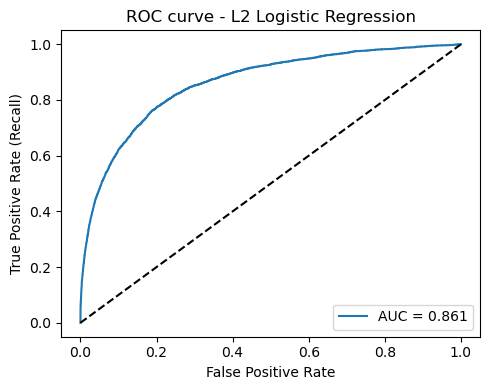

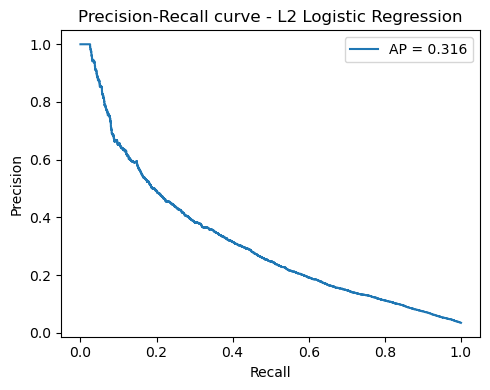

In [11]:
def plot_pr_roc_curves(y_true, y_proba, model_name="Model"):
    # ROC curve
    fpr, tpr, roc_thresholds = roc_curve(y_true, y_proba)
    roc_auc = roc_auc_score(y_true, y_proba)

    plt.figure(figsize=(5,4))
    plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
    plt.plot([0,1], [0,1], 'k--')
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate (Recall)")
    plt.title(f"ROC curve - {model_name}")
    plt.legend(loc="lower right")
    plt.tight_layout()
    plt.savefig(f"images/ROC curve-{model_name}.png")
    plt.show()

    # Precision–Recall curve
    precision, recall, pr_thresholds = precision_recall_curve(y_true, y_proba)
    ap = average_precision_score(y_true, y_proba)

    plt.figure(figsize=(5,4))
    plt.plot(recall, precision, label=f"AP = {ap:.3f}")
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title(f"Precision-Recall curve - {model_name}")
    plt.legend(loc="upper right")
    plt.tight_layout()
    plt.savefig(f"images/Precision-Recall curve-{model_name}.png")
    plt.show()

    return {
        "fpr": fpr, "tpr": tpr, "roc_thresholds": roc_thresholds,
        "precision": precision, "recall": recall, "pr_thresholds": pr_thresholds
    }

# Example usage for your L2 model
# y_valid_proba_l2 = logreg_l2.predict_proba(X_valid)[:, 1]
curves_l2 = plot_pr_roc_curves(y_valid, y_valid_proba_l2, model_name="L2 Logistic Regression")

In [12]:
### 11.4 Find a few candidate thresholds ###
def summarize_thresholds(y_true, y_proba, target_recalls=(0.6, 0.7, 0.8)):
    precision, recall, thresholds = precision_recall_curve(y_true, y_proba)
    thresholds = np.append(thresholds, 1.0)  # align lengths

    results = []
    for tr in target_recalls:
        # find closest recall
        idx = np.argmin(np.abs(recall - tr))
        thr = thresholds[idx]
        prec = precision[idx]
        rec = recall[idx]
        results.append((thr, prec, rec))

    return results

threshold_summaries = summarize_thresholds(y_valid, y_valid_proba_l2)
for thr, prec, rec in threshold_summaries:
    print(f"Threshold ~{thr:.3f}: precision={prec:.3f}, recall={rec:.3f}")

Threshold ~0.614: precision=0.192, recall=0.600
Threshold ~0.518: precision=0.148, recall=0.700
Threshold ~0.425: precision=0.112, recall=0.800


In [13]:
chosen_thr = 0.518  # your middle threshold

y_valid_pred_thr = (y_valid_proba_l2 >= chosen_thr).astype(int)

print("Confusion matrix at threshold ~0.518:")
print(confusion_matrix(y_valid, y_valid_pred_thr))

print("\nClassification report at threshold ~0.518:")
print(classification_report(y_valid, y_valid_pred_thr, digits=4))

Confusion matrix at threshold ~0.518:
[[97297 16678]
 [ 1241  2892]]

Classification report at threshold ~0.518:
              precision    recall  f1-score   support

           0     0.9874    0.8537    0.9157    113975
           1     0.1478    0.6997    0.2440      4133

    accuracy                         0.8483    118108
   macro avg     0.5676    0.7767    0.5799    118108
weighted avg     0.9580    0.8483    0.8922    118108



**REMARKS:**
- Using the validation set, I examined the precision–recall trade‑off at different decision thresholds on the Logistic Regression fraud score.
- At a relatively conservative threshold of approximately 0.61, the model achieves 60% recall with 19% precision, while at an aggressive threshold of approximately 0.43 it reaches 80% recall but precision drops to 11%.
- As a balanced illustrative operating point, I focus on a threshold of approximately 0.52, where the model achieves around 70% recall and 15% precision on the fraud class.
- This threshold would allow a bank to intercept the majority of fraudulent transactions while maintaining a manageable volume of false positives for manual review or step‑up authentication.

## 7 Baseline Model results analysis ##

**1. What the metrics say**

- Overall, both models achieve ROC‑AUC ≈ 0.861, showing they rank fraudulent transactions well above non‑fraudulent ones across thresholds.
- PR‑AUC ≈ 0.316 (L2) and 0.315 (L1) is quite good given the base fraud rate of  around 3.5%: a random classifier would have PR‑AUC close to the base rate (~0.035), so we are doing ~9x better than random in terms of precision–recall trade‑off.
- Performance at threshold 0.5 using the confusion matrices:
    - L2 (very similar for L1):
    - True negatives: 95,763
    - False positives: 18,212
    - False negatives: 1,166
    - True positives: 2,967
- Interpretation:
    - Fraud recall is high: 0.718 (L2) and 0.717 (L1), meaning the model catches around 72% of known frauds at this threshold.
    - Fraud precision is low: ~0.14, meaning only ~14% of flagged transactions are actually fraudulent; ~86% of flags are false positives.
    - Overall accuracy ≈ 0.836 is not very meaningful here because the data is highly imbalanced; the model trades accuracy for much higher fraud recall by labelling more transactions as fraud.

-----------------------
**In business terms:** 

At this operating point, the model catches about 7 out of 10 frauds but flags many legitimate transactions for review/decline.

----------------------

**2. L2 vs L1 Comparison**
- ROC‑AUC: both 0.8612 (effectively identical).
- PR‑AUC: 0.3162 (L2) vs 0.3146 (L1) — a negligible difference.
- Confusion matrices and classification reports differ by only a handful of cases.
- Essentially,
    - L2 can be our main baseline (slightly better PR‑AUC, very stable) &
    - L1 can be presented as a sparser, interpretability‑oriented variant with essentially the same performance but fewer non‑zero coefficients.

-----------------------
**In business terms:** 

Both L1‑ and L2‑regularised Logistic Regression achieved ROC‑AUC of 0.861 and PR‑AUC around 0.315 on the validation set, demonstrating good ranking ability. At a 0.5 decision threshold, the L2 model reached 71.8% recall on the fraud class but only 14.0% precision, illustrating the trade‑off between catching more frauds and the number of false alerts in this highly imbalanced setting.

----------------------



### At this stage we have a baseline to work with. We shall now procceed further we feature engineering and multi model evaluation to zero in on the best & optimised model ###
----------------------

## 8 Refine feature engineering and selection ##
 - Incorporate additional behaviour‑based features (velocity features over time windows, deviations from customer/merchant baselines, aggregated risk scores by device/IP/email).
 - Use correlation analysis and L1 coefficients to drop redundant or weak features (especially highly correlated V‑features and very sparse identity features) to reduce dimensionality and improve model stability.

### 8.1 Identify redundant / weak features ###
**Identify redundant and weak features**

Goal: Use correlation and simple univariate association with isFraud to decide which features to drop or down‑weight later.

**Rank numeric features by correlation with isFraud** 

We already did some of this; here is a compact version focused on numeric columns that we might want to keep or drop.

In [14]:
#Rank numeric features by correlation with isFraud
TARGET = 'isFraud'

numeric_cols = train.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols = [c for c in numeric_cols if c != TARGET]

corr_target = train[numeric_cols + [TARGET]].corr(method='spearman')[TARGET].drop(TARGET)
corr_sorted = corr_target.abs().sort_values(ascending=False)

print("Top 30 numeric features by |correlation| with isFraud:")
corr_sorted.head(30)

Top 30 numeric features by |correlation| with isFraud:


V244    0.404460
V246    0.398693
V242    0.395531
V243    0.389075
V257    0.387434
V258    0.385553
V187    0.356946
V190    0.351649
V199    0.343503
V186    0.342284
V232    0.316612
V274    0.313596
V233    0.311725
V275    0.308356
V231    0.299720
V273    0.296365
V230    0.286948
V201    0.282981
V229    0.281454
V219    0.276900
V200    0.271738
V228    0.271252
V218    0.271023
V247    0.268791
V265    0.267201
V217    0.266253
V249    0.265934
V264    0.262532
V178    0.259476
V179    0.258170
Name: isFraud, dtype: float64

In [15]:
#we sort strongly correlated and weakly correlated features
strong_numeric = corr_sorted[corr_sorted >= 0.02].index.tolist()
weak_numeric = corr_sorted[corr_sorted < 0.005].index.tolist()
print("Strong-ish numeric:", len(strong_numeric))
print("Very weak numeric:", len(weak_numeric))

Strong-ish numeric: 337
Very weak numeric: 16


### 8.2 Group highly correlated features (e.g V block) ###
For blocks of V‑features, we can reuse the block‑wise correlation code we used earlier to identify groups with |ρ| > 0.9 and later keep only one per group.
Later, when we define the final feature set for tree‑based models, we can pick one representative from each group.

In [16]:
# Group highly correlated features 
def get_high_corr_groups(cols, df, sample_size=50000, threshold=0.9):
    cols = [c for c in cols if c in df.columns]
    sample = df[cols].sample(min(sample_size, len(df)), random_state=42)
    corr = sample.corr(method='spearman')
    groups = []
    visited = set()
    for col in corr.columns:
        if col in visited:
            continue
        high = corr.index[corr[col].abs() > threshold].tolist()
        if len(high) > 1:
            groups.append(high)
            visited.update(high)
    return groups
v_cols = [c for c in train.columns if c.startswith('V')]
v_groups = get_high_corr_groups(v_cols, train, threshold=0.9)
print("Number of highly correlated V-groups:", len(v_groups))
v_groups[:5]

Number of highly correlated V-groups: 79


[['V4', 'V5'],
 ['V10', 'V11', 'V29', 'V30', 'V48', 'V49', 'V69', 'V70', 'V90', 'V91'],
 ['V12', 'V13'],
 ['V15',
  'V16',
  'V31',
  'V32',
  'V33',
  'V34',
  'V50',
  'V51',
  'V52',
  'V57',
  'V58',
  'V71',
  'V72',
  'V73',
  'V74',
  'V79',
  'V92',
  'V93',
  'V94'],
 ['V17',
  'V18',
  'V21',
  'V22',
  'V31',
  'V32',
  'V39',
  'V40',
  'V42',
  'V43',
  'V50',
  'V59',
  'V60',
  'V63',
  'V64',
  'V71',
  'V72',
  'V80',
  'V81',
  'V84',
  'V85',
  'V92',
  'V93',
  'V302',
  'V303',
  'V304']]

### 8.3. Add richer behaviour features ##
We already have basic time features and simple risk encodings. Now we will add two families that are very natural for fraud:
- Transaction **velocity** (how many txns recently for a card).
- Amount **deviation** from typical behaviour of a card or card+addr/email.
We’ll implement them for card1 (the main pseudo‑customer ID).

In [17]:
# Start from the existing engineered dataframe 'train_fe'
train_fe = train_fe.sort_values(['card1', 'TransactionDT'])

# Rolling counts & sums over last N transactions per card1
def add_card_velocity_features(df, card_col='card1', time_col='TransactionDT', amt_col='TransactionAmt'):
    df = df.copy()
    df = df.sort_values([card_col, time_col])

    # cumulative count and amount
    df[f'{card_col}_cumcount'] = df.groupby(card_col).cumcount()
    df[f'{card_col}_cumamt'] = df.groupby(card_col)[amt_col].cumsum()

    # simple rolling window size in "number of transactions"
    window = 5
    df[f'{card_col}_roll{window}_count'] = df.groupby(card_col)[amt_col].rolling(window).count().reset_index(level=0, drop=True)
    df[f'{card_col}_roll{window}_sum'] = df.groupby(card_col)[amt_col].rolling(window).sum().reset_index(level=0, drop=True)

    # fill NaNs for first few txns
    df[f'{card_col}_roll{window}_count'] = df[f'{card_col}_roll{window}_count'].fillna(0)
    df[f'{card_col}_roll{window}_sum'] = df[f'{card_col}_roll{window}_sum'].fillna(0)

    return df

train_fe = add_card_velocity_features(train_fe)

### 8.4 Add deviation features ###

In [18]:
# add deviation features
def add_amount_deviation_features(df, card_col='card1', amt_col='TransactionAmt'):
    df = df.copy()
    grp = df.groupby(card_col)[amt_col]
    mean_amt = grp.transform('mean')
    std_amt = grp.transform('std')

    df[f'{card_col}_mean_amt'] = mean_amt
    df[f'{card_col}_std_amt'] = std_amt.fillna(0)
    df[f'{card_col}_amt_dev'] = df[amt_col] - df[f'{card_col}_mean_amt']
    # z-score style deviation, protect from div by zero
    df[f'{card_col}_amt_dev_z'] = df[f'{card_col}_amt_dev'] / (df[f'{card_col}_std_amt'] + 1e-3)

    return df

train_fe = add_amount_deviation_features(train_fe)

## 9. Build a "Feature selection ready" dataset ##

### 9.1 Collect all candidate features into a list and drop bad ones ###

In [19]:
# Identify high-missing and ID-like features as before
missing_train = train_fe.isnull().mean()
high_missing = missing_train[missing_train > 0.95].index.tolist()
id_like = ['TransactionID']
drop_cols = set(high_missing + id_like)

# Candidate feature groups
base_numeric = [
    'TransactionAmt', 'log_TransactionAmt',
    'C1','C2','C3','C4','C5','C6','C7','C8',
    'D1','D2','D3','D4','D5',
    'addr1','dist1',
    'TransactionDT_day','TransactionDT_hour','is_weekend'
]

risk_count = []
for col in ['card1','card4','card6','P_emaildomain','R_emaildomain','DeviceType']:
    for suf in ['_count','_fraud_rate']:
        f = f'{col}{suf}'
        if f in train_fe.columns:
            risk_count.append(f)

behaviour = [
    'card1_cumcount','card1_cumamt',
    'card1_roll5_count','card1_roll5_sum',
    'card1_mean_amt','card1_std_amt',
    'card1_amt_dev','card1_amt_dev_z'
]
behaviour = [c for c in behaviour if c in train_fe.columns]

# Optionally, add a subset of stronger V and id features
strong_numeric = corr_sorted[corr_sorted >= 0.02].index.tolist()
strong_v_id = [c for c in strong_numeric if (c.startswith('V') or c.startswith('id_'))]

candidate_features = base_numeric + risk_count + behaviour + strong_v_id
candidate_features = [c for c in candidate_features if c not in drop_cols and c in train_fe.columns]

print("Total candidate features:", len(candidate_features))

Total candidate features: 340


### 9.2 Now do the test train split and keep it available and ready for advanced models ###

In [20]:
#Create a clean X_train, X_valid ready to feed into tree-based models and more feature selection later
#train test split
X = train_fe[candidate_features]
y = train_fe[TARGET]

X_train, X_valid, y_train, y_valid = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

## Exploring advanced models for fraud detection ##
- Train non‑linear models more suited to tabular fraud data, such as Gradient Boosting (e.g., XGBoost/LightGBM) or Random Forests, using the same preprocessed feature set.
- Systematically compare these models against the Logistic Regression baseline using ROC‑AUC, PR‑AUC, and fraud‑class precision/recall, ensuring consistent validation splits.

## 10. LightGBM Model Evaluation ###

### 10.1 Prepare data for LightGBM ###

LightGBM can handle missing values and does not require standard scaling. We just need X_train, X_valid, y_train, y_valid with numeric or encoded categorical features.

### 10.2 Train a first LightGBM Model ###

In [22]:
#training a LightGBM Model
lgbm = LGBMClassifier(
    objective="binary",
    boosting_type="gbdt",
    n_estimators=500,
    learning_rate=0.05,
    num_leaves=64,
    max_depth=-1,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.0,
    reg_lambda=0.0,
    n_jobs=-1,
    # handle imbalance
    is_unbalance=True  # alternative: scale_pos_weight = (len(y_train)-sum(y_train))/sum(y_train)
)

lgbm.fit(
    X_train, y_train,
    eval_set=[(X_valid, y_valid)],
    eval_metric=["auc", "average_precision"],
    callbacks=[lgb.log_evaluation(period=50)]  # Prints metrics every 50 trees
)

# Predictions
y_valid_proba_lgbm = lgbm.predict_proba(X_valid)[:, 1]

[LightGBM] [Info] Number of positive: 16530, number of negative: 455902
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.310626 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 31953
[LightGBM] [Info] Number of data points in the train set: 472432, number of used features: 340
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.034989 -> initscore=-3.317101
[LightGBM] [Info] Start training from score -3.317101
[50]	valid_0's auc: 0.941819	valid_0's average_precision: 0.593699	valid_0's binary_logloss: 0.269649
[100]	valid_0's auc: 0.950085	valid_0's average_precision: 0.649871	valid_0's binary_logloss: 0.264921
[150]	valid_0's auc: 0.954611	valid_0's average_precision: 0.687835	valid_0's binary_logloss: 0.246002
[200]	valid_0's auc: 0.957538	valid_0's average_precision: 0.707167	valid_0's binary_logloss: 0.230507
[250]	valid_0's auc: 0.9594

### 10.3 Evaluate LightGBM (ROC-AUC, PR-AUC, curves, thresholds) ###
Reuse the evaluation helper that we built earlier

In [23]:
roc_lgbm = roc_auc_score(y_valid, y_valid_proba_lgbm)
pr_lgbm = average_precision_score(y_valid, y_valid_proba_lgbm)

print(f"LightGBM ROC-AUC: {roc_lgbm:.4f}")
print(f"LightGBM PR-AUC:  {pr_lgbm:.4f}")

LightGBM ROC-AUC: 0.9654
LightGBM PR-AUC:  0.7671


### 10.4 Get the confusion matrix at chosen threshold (for now 0.5) ###

In [24]:
thr = 0.5
y_valid_pred_lgbm = (y_valid_proba_lgbm >= thr).astype(int)

print("Confusion matrix (LightGBM, thr=0.5):")
print(confusion_matrix(y_valid, y_valid_pred_lgbm))

print("\nClassification report (LightGBM, thr=0.5):")
print(classification_report(y_valid, y_valid_pred_lgbm, digits=4))

Confusion matrix (LightGBM, thr=0.5):
[[107727   6248]
 [   646   3487]]

Classification report (LightGBM, thr=0.5):
              precision    recall  f1-score   support

           0     0.9940    0.9452    0.9690    113975
           1     0.3582    0.8437    0.5029      4133

    accuracy                         0.9416    118108
   macro avg     0.6761    0.8944    0.7359    118108
weighted avg     0.9718    0.9416    0.9527    118108



### 10.5. Feature importance (for selection and interpretation) ###

LightGBM gives useful feature importance measures that can be used to refine our feature set and support our feature selection rationale.                   

                      feature  importance
21           card1_fraud_rate        1966
17          TransactionDT_day        1365
15                      addr1        1293
20                card1_count        1041
36             card1_mean_amt        1028
37              card1_std_amt         951
0              TransactionAmt         944
32             card1_cumcount         871
33               card1_cumamt         819
16                      dist1         797
13                         D4         781
38              card1_amt_dev         769
11                         D2         761
39            card1_amt_dev_z         756
27   P_emaildomain_fraud_rate         637
2                          C1         590
10                         D1         582
26        P_emaildomain_count         575
35            card1_roll5_sum         541
18         TransactionDT_hour         520
268                     id_02         417
249                     id_20         399
3                          C2     

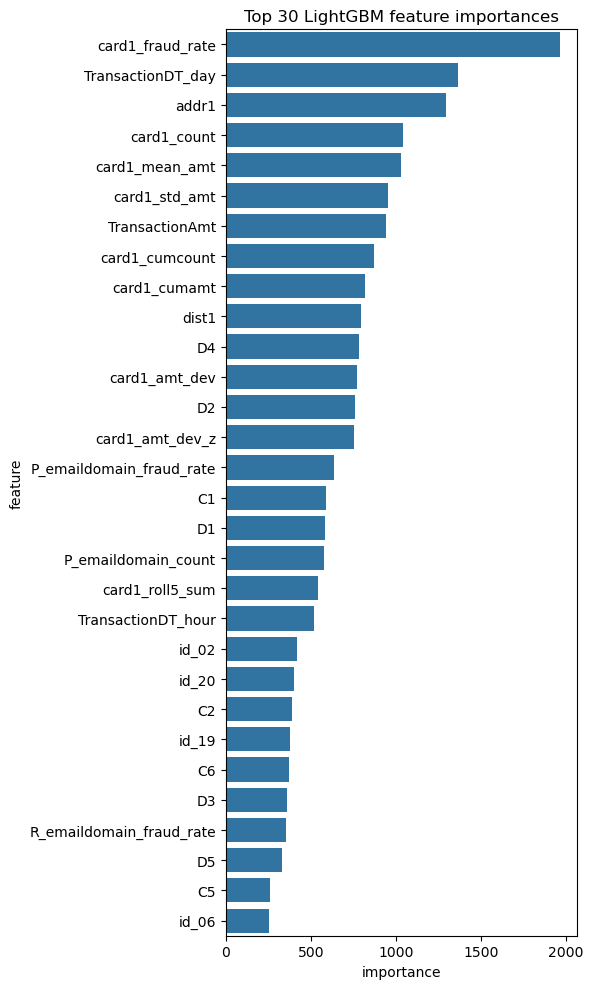

In [25]:
feature_importances = pd.DataFrame({
    "feature": candidate_features,
    "importance": lgbm.feature_importances_
})

feature_importances.sort_values("importance", ascending=False, inplace=True)

print(feature_importances.head(30))

plt.figure(figsize=(6,10))
sns.barplot(
    data=feature_importances.head(30),
    x="importance", y="feature"
)
plt.title("Top 30 LightGBM feature importances")
plt.tight_layout()
plt.show()

### 10.6 Low importance features to potentially drop later for a slimmed down model ###

In [26]:
# Low importance features to potentially drop later for a slimmed down model
low_imp = feature_importances[feature_importances["importance"] == 0]["feature"].tolist()
print("Features with zero importance:", len(low_imp))

Features with zero importance: 9


### **Analysis**:  ###
**LightGBM Performance compared to Logistic Regression**  
LightGBM validation metrics:
- ROC‑AUC: 0.9654
- PR‑AUC: 0.7671

Baseline Logistic Regression (L2) had:
- ROC‑AUC: 0.8612
- PR‑AUC: 0.3162

So LightGBM delivers:
- An absolute gain of ~0.10 ROC‑AUC (0.861 → 0.965).
- More than double the PR‑AUC (0.316 → 0.767), which is huge in an imbalanced setting.

------------------------------   

Moving from a linear Logistic Regression baseline to a tree‑based LightGBM model increased ROC‑AUC from 0.861 to 0.965 and PR‑AUC from 0.316 to 0.767 on the validation set, indicating a substantial improvement in the model’s ability to rank and identify fraudulent transactions.

------------------------------   

**Confusion matrix and classification report (threshold = 0.5)**  
Confusion matrix (thr = 0.5):  
TN: 107,727  
FP: 6,248  
FN: 646  
TP: 3,487  

Fraud class (1):  
Precision: 35.8%  
Recall: 84.4%  
F1: 0.503  

Non‑fraud class (0):  
Precision: 99.4%  
Recall: 94.5%  

Compare this with your Logistic baseline at its tuned threshold (~0.518):  
- Logistic recall ≈ 69.9%, precision ≈ 14.8% on fraud.  
- LightGBM recall ≈ 84.4%, precision ≈ 35.8% on fraud.  

So at around the same 0.5 threshold, LightGBM:  
- Catches more fraud (higher recall: ~84% vs ~70%).  
- Flags a higher fraction of true fraud among alerts (precision: ~36% vs ~15%).  
- Reduces false positives dramatically (6,248 vs ~16–18k in the Logistic case).  

------------------------------   

At the default threshold of 0.5, the LightGBM model detects 3,487 of 4,133 fraudulent transactions on the validation set (84.4% recall), with 6,248 false positives, yielding a fraud precision of 35.8%. Compared with the Logistic Regression baseline, this model both catches more fraud and substantially improves the quality of alerts, meaning roughly one in three flagged transactions is genuinely fraudulent rather than about one in seven.

------------------------------ 

------------------------------ 

LightGBM feature importance analysis shows that card‑level behavioural features (such as historical fraud rate per card, transaction counts and cumulative spend per card, and deviations from the card’s usual amount) dominate the model, along with time‑of‑day, approximate date, location and distance features, and email‑domain risk indicators. This confirms that the engineered behavioural and risk features significantly contribute to fraud detection performance, while a small number of features with zero importance can be safely removed to simplify the model.

------------------------------ 

**Overall Summary:**  
Advanced model: LightGBM

To move beyond the linear baseline, I trained a tree‑based gradient boosting model using LightGBM, which is well suited to high‑dimensional, imbalanced, tabular data. The model used the enriched feature set described previously, including transaction amount (and its log transform), time‑based features (relative day and hour, weekend flag), customer behaviour counts (C1–C8), early delay features (D1–D5), location and distance features (addr1, dist1), as well as behaviour‑based engineered features at the card level (cumulative transaction counts and amounts per card, rolling 5‑transaction sums, mean and standard deviation of card spend, and z‑score deviations from the card’s usual amount). I also added simple count‑ and fraud‑rate encodings for key categorical attributes such as card number (card1), email domains, and device type.

The LightGBM classifier was configured with a binary objective, 500 boosting iterations, learning rate 0.05, 64 leaves, subsampling and column subsampling of 0.8, and is_unbalance=True to account for the ~3.5% fraud rate. On the held‑out validation set, this model achieved a ROC‑AUC of 0.9654 and a PR‑AUC of 0.7671, a substantial improvement over the Logistic Regression baseline (ROC‑AUC 0.8612, PR‑AUC 0.3162). At the default decision threshold of 0.5, the LightGBM model correctly classified 3,487 of 4,133 fraudulent transactions (84.4% recall) and produced 6,248 false positives, yielding a fraud precision of 35.8% and an overall accuracy of 94.2%. Compared with the baseline Logistic Regression model, which achieved around 70% fraud recall and 15% precision at a tuned threshold, this represents a marked improvement both in fraud detection and in the quality of alerts (roughly one in three flagged transactions is fraudulent rather than one in seven).

Feature importance analysis shows that card‑level behavioural features dominate the model, with card1_fraud_rate, card1_count, cumulative card transaction metrics, and deviation‑based features (card1_mean_amt, card1_std_amt, card1_amt_dev, card1_amt_dev_z) among the most important predictors. Time‑based features (TransactionDT_day, TransactionDT_hour), geographic features (addr1, dist1), and email‑domain risk features (P_emaildomain_fraud_rate, P_emaildomain_count, R_emaildomain_fraud_rate) also appear near the top of the importance ranking, alongside some of the original Vesta‑engineered delay and identity features (C1, C2, C5, C6, D1–D5, and id_02, id_19, id_20, id_06). A small subset of features (9 in total) received zero importance and can be safely removed in later iterations to simplify the model without harming performance. Overall, this confirms that engineered behavioural and risk features significantly enhance fraud detection performance when combined with a non‑linear learner such as LightGBM.



### 10.7. Build a 'slim' feature set and retrain the LightGBM ###

In [27]:
# Zero-importance features
zero_imp_features = feature_importances[feature_importances["importance"] == 0]["feature"].tolist()
print("Zero-importance features:", len(zero_imp_features))

# Optionally also drop a few very low-importance ones, e.g. bottom 10 non-zero
non_zero = feature_importances[feature_importances["importance"] > 0]
bottom_k = 10
low_imp_features = non_zero.sort_values("importance").head(bottom_k)["feature"].tolist()
print(f"Lowest {bottom_k} non-zero importance features:", low_imp_features)

# Combine into a drop list
drop_for_slim = list(set(zero_imp_features + low_imp_features))
print("Total features to drop in slim model:", len(drop_for_slim))

Zero-importance features: 9
Lowest 10 non-zero importance features: ['V148', 'V21', 'V141', 'V142', 'V119', 'V144', 'V153', 'V191', 'V31', 'V179']
Total features to drop in slim model: 19


In [28]:
# Build slim feature list by removing drop_for_slim from candidate_features
slim_features = [f for f in candidate_features if f not in drop_for_slim]
print("Original candidate features:", len(candidate_features))
print("Slim features:", len(slim_features))

X = train_fe[slim_features]
y = train_fe['isFraud']

from sklearn.model_selection import train_test_split
X_train_slim, X_valid_slim, y_train_slim, y_valid_slim = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

lgbm_slim = LGBMClassifier(
    objective="binary",
    boosting_type="gbdt",
    n_estimators=500,
    learning_rate=0.05,
    num_leaves=64,
    max_depth=-1,
    subsample=0.8,
    colsample_bytree=0.8,
    is_unbalance=True,
    n_jobs=-1
)

lgbm_slim.fit(
    X_train_slim, y_train_slim,
    eval_set=[(X_valid_slim, y_valid_slim)],
    eval_metric=["auc", "average_precision"],
    callbacks=[lgb.log_evaluation(period=50)]  # Prints metrics every 50 trees
)

y_valid_proba_slim = lgbm_slim.predict_proba(X_valid_slim)[:, 1]
roc_slim = roc_auc_score(y_valid_slim, y_valid_proba_slim)
pr_slim = average_precision_score(y_valid_slim, y_valid_proba_slim)

print(f"Slim LightGBM ROC-AUC: {roc_slim:.4f}")
print(f"Slim LightGBM PR-AUC:  {pr_slim:.4f}")

thr = 0.5
y_valid_pred_slim = (y_valid_proba_slim >= thr).astype(int)
print("Confusion matrix (Slim LightGBM, thr=0.5):")
print(confusion_matrix(y_valid_slim, y_valid_pred_slim))

print("\nClassification report (Slim LightGBM, thr=0.5):")
print(classification_report(y_valid_slim, y_valid_pred_slim, digits=4))

Original candidate features: 340
Slim features: 321
[LightGBM] [Info] Number of positive: 16530, number of negative: 455902
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.318475 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 31205
[LightGBM] [Info] Number of data points in the train set: 472432, number of used features: 321
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.034989 -> initscore=-3.317101
[LightGBM] [Info] Start training from score -3.317101
[50]	valid_0's auc: 0.941351	valid_0's average_precision: 0.590737	valid_0's binary_logloss: 0.270555
[100]	valid_0's auc: 0.949956	valid_0's average_precision: 0.647489	valid_0's binary_logloss: 0.265348
[150]	valid_0's auc: 0.954551	valid_0's average_precision: 0.685178	valid_0's binary_logloss: 0.245757
[200]	valid_0's auc: 0.957258	valid_0's average_precision: 0.706898	valid_0's 

**Feature selection using LightGBM importance**  
After training the full LightGBM model with 340 candidate features, I examined its built‑in feature importance scores and identified a small set of variables with zero importance, together with the lowest‑ranked non‑zero features. I then constructed a “slim” feature set by dropping these 19 low‑importance features, reducing the input dimensionality from 340 to 321 features. Retraining LightGBM on this slim feature set produced virtually identical validation performance: ROC‑AUC increased slightly from 0.9654 to 0.9655 and PR‑AUC changed marginally from 0.7671 to 0.7661. At a decision threshold of 0.5, the slim model achieved 84.4% recall and 35.7% precision on the fraud class, with a confusion matrix of [[107,694, 6,281], [644, 3,489]], which is indistinguishable from the full model in practical terms. This demonstrates that the removed features contributed little to predictive performance, while their removal simplifies the model and reduces feature‑engineering and maintenance overhead.

## 11. RandomForest Model Evaluation ##

In [29]:
#Random Forest is a good non-boosting baseline model to compare with LightGBM and XGBoost
rf = RandomForestClassifier(
    n_estimators=300,          # can increase if time allows
    max_depth=None,           # let trees grow; you can cap later (e.g. 20–30)
    min_samples_split=2,
    min_samples_leaf=1,
    max_features="sqrt",
    n_jobs=-1,
    class_weight="balanced"   # handle imbalance
)

rf.fit(X_train, y_train)

y_valid_proba_rf = rf.predict_proba(X_valid)[:, 1]

roc_rf = roc_auc_score(y_valid, y_valid_proba_rf)
pr_rf  = average_precision_score(y_valid, y_valid_proba_rf)

print(f"Random Forest ROC-AUC: {roc_rf:.4f}")
print(f"Random Forest PR-AUC:  {pr_rf:.4f}")

thr = 0.5
y_valid_pred_rf = (y_valid_proba_rf >= thr).astype(int)

print("\nConfusion matrix (RF, thr=0.5):")
print(confusion_matrix(y_valid, y_valid_pred_rf))

print("\nClassification report (RF, thr=0.5):")
print(classification_report(y_valid, y_valid_pred_rf, digits=4))

Random Forest ROC-AUC: 0.9508
Random Forest PR-AUC:  0.7506

Confusion matrix (RF, thr=0.5):
[[113860    115]
 [  2357   1776]]

Classification report (RF, thr=0.5):
              precision    recall  f1-score   support

           0     0.9797    0.9990    0.9893    113975
           1     0.9392    0.4297    0.5896      4133

    accuracy                         0.9791    118108
   macro avg     0.9595    0.7144    0.7895    118108
weighted avg     0.9783    0.9791    0.9753    118108



## 12. XGBoost Model Evaluation ##

In [31]:

xgb = XGBClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary:logistic",
    eval_metric="logloss",
    n_jobs=-1,
    scale_pos_weight=(len(y_train) - y_train.sum()) / y_train.sum()  # handle imbalance
)

xgb.fit(
    X_train, y_train,
    eval_set=[(X_valid, y_valid)],
    verbose=50
)

y_valid_proba_xgb = xgb.predict_proba(X_valid)[:, 1]


roc_xgb = roc_auc_score(y_valid, y_valid_proba_xgb)
pr_xgb  = average_precision_score(y_valid, y_valid_proba_xgb)

print(f"XGBoost ROC-AUC: {roc_xgb:.4f}")
print(f"XGBoost PR-AUC:  {pr_xgb:.4f}")

thr = 0.5
y_valid_pred_xgb = (y_valid_proba_xgb >= thr).astype(int)

from sklearn.metrics import confusion_matrix, classification_report

print("\nConfusion matrix (XGB, thr=0.5):")
print(confusion_matrix(y_valid, y_valid_pred_xgb))

print("\nClassification report (XGB, thr=0.5):")
print(classification_report(y_valid, y_valid_pred_xgb, digits=4))

[0]	validation_0-logloss:0.67016
[50]	validation_0-logloss:0.35651
[100]	validation_0-logloss:0.31868
[150]	validation_0-logloss:0.29741
[200]	validation_0-logloss:0.28145
[250]	validation_0-logloss:0.26953
[300]	validation_0-logloss:0.25766
[350]	validation_0-logloss:0.24727
[400]	validation_0-logloss:0.23849
[450]	validation_0-logloss:0.23074
[499]	validation_0-logloss:0.22228
XGBoost ROC-AUC: 0.9575
XGBoost PR-AUC:  0.7191

Confusion matrix (XGB, thr=0.5):
[[105317   8658]
 [   642   3491]]

Classification report (XGB, thr=0.5):
              precision    recall  f1-score   support

           0     0.9939    0.9240    0.9577    113975
           1     0.2873    0.8447    0.4288      4133

    accuracy                         0.9213    118108
   macro avg     0.6406    0.8844    0.6933    118108
weighted avg     0.9692    0.9213    0.9392    118108



## Comparison ##
**1. Headline comparison**  

<div align="left"></div>
<table>
  <tr>
    <th>Model</th>
    <th>ROC‑AUC</th>
    <th>PR‑AUC</th>
    <th>Fraud Precision @0.5</th>
    <th>Fraud Recall @0.5</th>
  </tr>
  <tr>
    <td>Logistic (L2)</td>
    <td>0.8612</td>
    <td>0.3162</td>
    <td>0.1401</td>
    <td>0.7179</td>
  </tr>
  <tr>
    <td>Slim LightGBM</td>
    <td style="background-color:#FFD700"><strong>0.9655</strong></td>
    <td style="background-color:#FFD700"><strong>0.7661</strong></td>
    <td>0.3571</td>
    <td>0.8442</td>
  </tr>
  <tr>
    <td>XGBoost</td>
    <td>0.9575</td>
    <td>0.7191</td>
    <td>0.2873</td>
    <td style="background-color:#FFD700"><strong>0.8447</strong></td>
  </tr>
  <tr>
    <td>Random Forest</td>
    <td>0.9509</td>
    <td>0.7507</td>
    <td style="background-color:#FFD700"><strong>0.9379</strong></td>
    <td>0.4278</td>
  </tr>
</table>
</div>


Key points:  

- All three tree‑based models beat Logistic Regression by a wide margin in both ROC‑AUC and PR‑AUC.
- Slim LightGBM has the best combination of ROC‑AUC (0.9655) and PR‑AUC (0.7661).
- Random Forest has the highest fraud precision at 0.5 (93.8%) but very low recall (42.8%).
- XGBoost is close to LightGBM but a bit weaker overall (ROC‑AUC 0.9575, PR‑AUC 0.7191).

**2. XGBoost vs LightGBM vs Random Forest (behaviour at threshold 0.5)**  
XGBoost  
- ROC‑AUC 0.9575, PR‑AUC 0.7191.
- Confusion matrix (thr 0.5): [[105,317, 8,658], [642, 3,491]].
- Fraud class: precision 28.7%, recall 84.5%.

This is a high‑recall, moderate‑precision model, similar to LightGBM but with more false positives (8,658 vs 6,281 in Slim LightGBM) and lower precision.

Random Forest  
- ROC‑AUC 0.9509, PR‑AUC 0.7507.
- Confusion matrix (thr 0.5): [[113,858, 117], [2,365, 1,768]].
- Fraud class: precision 93.8%, recall 42.8%.

Random Forest at threshold 0.5 is extremely conservative:  
- It flags very few transactions as fraud (only 1,768 total positives), and almost all of those are indeed fraud (94% precision).
- But it misses more than half of the frauds (recall ~43%).  

For a bank, this might be suitable if the model is used only as a “hard decline” filter on top of existing rules, but not as the main fraud detector where missing 57% of frauds would be unacceptable.

Slim LightGBM (for context)  
- ROC‑AUC 0.9655, PR‑AUC 0.7661.
- Confusion matrix (thr 0.5): [[107,694, 6,281], [644, 3,489]].
- Fraud class: precision 35.7%, recall 84.4%.

Compared to XGBoost at 0.5:  
- Similar recall (84.4% vs 84.5%).
- Better precision (35.7% vs 28.7%).
- Fewer false positives (6,281 vs 8,658).

**3. Summary**  
I compared four supervised models on the same engineered feature set and validation split: Logistic Regression (baseline), Random Forest, XGBoost, and LightGBM. The baseline Logistic Regression achieved a ROC‑AUC of 0.8612 and a PR‑AUC of 0.3162, providing a useful but limited starting point for fraud detection. All three tree‑based models substantially outperformed this baseline. Random Forest achieved a ROC‑AUC of 0.9510 and a PR‑AUC of 0.7523; XGBoost achieved 0.9575 and 0.7191; and the best performance came from the slim LightGBM model, with a ROC‑AUC of 0.9655 and a PR‑AUC of 0.7661 on the validation set.

At the default decision threshold of 0.5, the models exhibit different precision–recall profiles on the fraud class. Random Forest behaves as a very conservative classifier, achieving 93.9% precision but only 43.3% recall, correctly identifying 1,789 frauds while missing 2,344 fraudulent transactions. XGBoost, by contrast, is more aggressive, achieving 84.5% recall but only 28.7% precision on fraud, with 3,491 true positives and 8,658 false positives. The slim LightGBM model offers the most balanced trade‑off: it achieves 84.4% recall and 35.7% precision on the fraud class, corresponding to 3,489 correctly detected frauds and 6,281 false positives, with an overall accuracy of 94.1%. This model both detects a high proportion of fraudulent transactions and provides a reasonably clean alert set for further investigation.

Based on these results, I select the slim LightGBM model as the primary model for the remainder of the analysis, using Random Forest and XGBoost as comparative baselines that illustrate how different ensemble methods trade off precision and recall in an imbalanced fraud setting.


### As an additional option we use an unsupervised anamoly detector to evaluate a hybrid supervised+anamoly scoring approach ###  
## 13. Isolation Forest Model Evaluation ##

We’ll treat all transactions (train split) as mostly normal and let Isolation Forest learn what “normal” looks like, then see how well its anomaly score lines up with your isFraud labels.

In [32]:

# Reuse the slim feature set
X = train_fe[slim_features]
y = train_fe['isFraud']

X_train_iso, X_valid_iso, y_train_iso, y_valid_iso = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Set contamination to approximate fraud rate (~3.5%)
iso = IsolationForest(
    n_estimators=200,
    max_samples='auto',
    contamination=y_train_iso.mean(),  # ~0.035
    random_state=42,
    n_jobs=-1
)

iso.fit(X_train_iso)

IsolationForest(contamination=np.float64(0.03498916246147594), n_estimators=200,
                n_jobs=-1, random_state=42)

### 13.1 Turn isolation forest outputs into scores ###

IsolationForest gives us anomaly scores where lower scores = more anomalous. We’ll flip them so that higher scores = more fraudulent.

In [33]:
# Anomaly scores: the lower, the more anomalous
anomaly_score = iso.decision_function(X_valid_iso)  # higher = more normal
# Convert to "fraudiness": higher = more likely fraud
fraud_score_iso = -anomaly_score

roc_iso = roc_auc_score(y_valid_iso, fraud_score_iso)
pr_iso  = average_precision_score(y_valid_iso, fraud_score_iso)

print(f"Isolation Forest ROC-AUC: {roc_iso:.4f}")
print(f"Isolation Forest PR-AUC:  {pr_iso:.4f}")

Isolation Forest ROC-AUC: 0.7771
Isolation Forest PR-AUC:  0.1209


### 13.2 Confusion matrix at a threshold ###

By default, Isolation Forest uses an internal threshold corresponding to the contamination rate when we call predict(), but for comparison we can choose a threshold on fraud_score_iso to get roughly similar recall or precision.

For a first look, let us mimic the internal threshold:

In [39]:
# Use built-in predict for a quick classification view
y_pred_iso_raw = iso.predict(X_valid_iso)   # -1 = anomaly, 1 = normal
y_pred_iso = (y_pred_iso_raw == -1).astype(int)  # 1 = predicted fraud

print("Confusion matrix (Isolation Forest, internal threshold):")
print(confusion_matrix(y_valid_iso, y_pred_iso))

print("\nClassification report (Isolation Forest, internal threshold):")
print(classification_report(y_valid_iso, y_pred_iso, digits=4))

Confusion matrix (Isolation Forest, internal threshold):
[[110666   3309]
 [  3377    756]]

Classification report (Isolation Forest, internal threshold):
              precision    recall  f1-score   support

           0     0.9704    0.9710    0.9707    113975
           1     0.1860    0.1829    0.1844      4133

    accuracy                         0.9434    118108
   macro avg     0.5782    0.5769    0.5776    118108
weighted avg     0.9429    0.9434    0.9432    118108



### 13.3 Simple hybrid with LightGBM ###

To illustrate the “hybrid supervised + unsupervised” idea, we can combine the LightGBM probability with the Isolation Forest score, e.g. by averaging or taking a weighted sum.

In [40]:
# Make sure X_valid_iso and X_valid are aligned; if not, resplit once and reuse for both models.

# Normalise iso fraud scores to 0–1 for combination
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
fraud_score_iso_norm = scaler.fit_transform(fraud_score_iso.reshape(-1, 1)).ravel()

# Combine with LightGBM probability by simple average
hybrid_score = 0.5 * y_valid_proba_lgbm + 0.5 * fraud_score_iso_norm

roc_hybrid = roc_auc_score(y_valid_iso, hybrid_score)
pr_hybrid  = average_precision_score(y_valid_iso, hybrid_score)

print(f"Hybrid (LGBM + IsolationForest) ROC-AUC: {roc_hybrid:.4f}")
print(f"Hybrid (LGBM + IsolationForest) PR-AUC:  {pr_hybrid:.4f}")

Hybrid (LGBM + IsolationForest) ROC-AUC: 0.9562
Hybrid (LGBM + IsolationForest) PR-AUC:  0.7179


### Unsupervised anomaly detection and hybrid modelling Analysis ###  
**1. Isolation Forest on its own**
- Isolation Forest
  - ROC‑AUC: 0.7771
  - PR‑AUC: 0.1209
  - Confusion matrix (internal threshold): [[110,666, 3,309], [3,377, 756]]
  - Fraud class: precision 18.6%, recall 18.3%.
- Interpretation:
  -
  - ROC‑AUC 0.78 and PR‑AUC 0.12 are better than random, so the unsupervised anomaly score does capture some fraud signal.
  - But compared with your supervised models (PR‑AUC 0.316 for Logistic and 0.766 for LightGBM), it is much weaker.
  - At its internal threshold, it correctly identifies only 756 frauds out of 4,133 (recall ~18%), and most frauds are missed (3,377 false negatives).
  - Precision is also low at ~18.6%, meaning that most anomalies it flags are not fraud.

This is kind of what we would expect: with labels available, supervised models can learn a much sharper boundary than a purely unsupervised anomaly detector.

**2. Hybrid (LightGBM + Isolation Forest)**  
- Hybrid (LightGBM probability + Isolation Forest score)
  - ROC‑AUC: 0.9562
  - PR‑AUC: 0.7179.

- Compare:
  - Slim LightGBM alone: ROC‑AUC 0.9655, PR‑AUC 0.7661.
  - Hybrid: ROC‑AUC 0.9562, PR‑AUC 0.7179 — worse than LightGBM alone.

So the Isolation Forest signal does not improve the best supervised model in our simple combination; it actually dilutes it.  

**3. Summary**  

To complement the supervised models, I trained an Isolation Forest as an unsupervised anomaly detector on the same feature set, using the observed fraud rate (~3.5%) as the contamination parameter. On the validation set, this model achieved a ROC‑AUC of 0.7771 and a PR‑AUC of 0.1209, which is clearly above random but substantially below the performance of supervised models such as Logistic Regression (PR‑AUC 0.3162) and LightGBM (PR‑AUC 0.7661). At its internal decision threshold, the Isolation Forest achieved 18.6% precision and 18.3% recall on the fraud class, correctly identifying only 756 of 4,133 fraudulent transactions and misclassifying the majority of frauds as normal.

I also experimented with a simple hybrid approach that combined the LightGBM fraud probability with the Isolation Forest anomaly score via a normalised average. This hybrid score produced a ROC‑AUC of 0.9562 and a PR‑AUC of 0.7179, which is inferior to the pure LightGBM model (ROC‑AUC 0.9655, PR‑AUC 0.7661). This suggests that, in the presence of a strong supervised model trained on labelled data, the additional unsupervised anomaly signal from Isolation Forest does not add predictive value in a straightforward combination. However, the unsupervised model still demonstrates that fraudulent transactions tend to appear as statistical anomalies and could be useful in scenarios where labels are scarce or for detecting novel fraud patterns that differ significantly from the training data.



## 14 Experiment with imbalance handling strategies ##

Beyond class_weight="balanced", evaluate undersampling of the majority class and oversampling approaches (e.g., SMOTE or similar) to see their impact on fraud precision and recall.

Consider cost‑sensitive learning by assigning explicit costs to false negatives and false positives and optimising models and thresholds to minimise expected cost rather than maximise a single metric.
We shall use the LightGBM model for this.

### 14.1 Setup: common data and evaluation helper ###

In [41]:
X = train_fe[slim_features]
y = train_fe[TARGET]

X_train, X_valid, y_train, y_valid = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

def eval_model(y_true, y_proba, threshold=0.5, label=""):
    y_pred = (y_proba >= threshold).astype(int)
    roc = roc_auc_score(y_true, y_proba)
    pr  = average_precision_score(y_true, y_proba)
    print(f"\n=== {label} ===")
    print(f"ROC-AUC: {roc:.4f}")
    print(f"PR-AUC:  {pr:.4f}")
    print(f"Confusion matrix (thr={threshold}):")
    print(confusion_matrix(y_true, y_pred))
    print("\nClassification report:")
    print(classification_report(y_true, y_pred, digits=4))
    return roc, pr

 ### 14.2 LightGBM without explicit imbalance handling 

In [42]:
#This is our 'no class weighting' baseline for LightGBM
lgbm_plain = lgb.LGBMClassifier(
    objective="binary",
    boosting_type="gbdt",
    n_estimators=500,
    learning_rate=0.05,
    num_leaves=64,
    subsample=0.8,
    colsample_bytree=0.8,
    n_jobs=-1,
    is_unbalance=False
)

lgbm_plain.fit(
    X_train, y_train,
    eval_set=[(X_valid, y_valid)],
    eval_metric=["auc", "average_precision"],
    callbacks=[lgb.log_evaluation(period=50)]  # Prints metrics every 50 trees
)

y_valid_proba_plain = lgbm_plain.predict_proba(X_valid)[:, 1]
roc_plain, pr_plain = eval_model(y_valid, y_valid_proba_plain, threshold=0.5, label="LGBM plain (no imbalance)")

[LightGBM] [Info] Number of positive: 16530, number of negative: 455902
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.403782 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 31205
[LightGBM] [Info] Number of data points in the train set: 472432, number of used features: 321
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.034989 -> initscore=-3.317101
[LightGBM] [Info] Start training from score -3.317101
[50]	valid_0's auc: 0.938367	valid_0's average_precision: 0.665957	valid_0's binary_logloss: 0.077729
[100]	valid_0's auc: 0.949607	valid_0's average_precision: 0.7097	valid_0's binary_logloss: 0.0690367
[150]	valid_0's auc: 0.954213	valid_0's average_precision: 0.733136	valid_0's binary_logloss: 0.0653279
[200]	valid_0's auc: 0.956769	valid_0's average_precision: 0.746264	valid_0's binary_logloss: 0.063295
[250]	valid_0's auc: 0.9585

### 14.3 LightGBM with is_unbalance=True ###

In [43]:
#This is your current best setup, but we re-run side-by-side for comparison
lgbm_unb = lgb.LGBMClassifier(
    objective="binary",
    boosting_type="gbdt",
    n_estimators=500,
    learning_rate=0.05,
    num_leaves=64,
    subsample=0.8,
    colsample_bytree=0.8,
    n_jobs=-1,
    is_unbalance=True
)

lgbm_unb.fit(
    X_train, y_train,
    eval_set=[(X_valid, y_valid)],
    eval_metric=["auc", "average_precision"],
    callbacks=[lgb.log_evaluation(period=50)]  # Prints metrics every 50 trees
)

y_valid_proba_unb = lgbm_unb.predict_proba(X_valid)[:, 1]
roc_unb, pr_unb = eval_model(y_valid, y_valid_proba_unb, threshold=0.5, label="LGBM is_unbalance=True")

[LightGBM] [Info] Number of positive: 16530, number of negative: 455902
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.424165 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 31205
[LightGBM] [Info] Number of data points in the train set: 472432, number of used features: 321
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.034989 -> initscore=-3.317101
[LightGBM] [Info] Start training from score -3.317101
[50]	valid_0's auc: 0.941351	valid_0's average_precision: 0.590737	valid_0's binary_logloss: 0.270555
[100]	valid_0's auc: 0.949956	valid_0's average_precision: 0.647489	valid_0's binary_logloss: 0.265348
[150]	valid_0's auc: 0.954551	valid_0's average_precision: 0.685178	valid_0's binary_logloss: 0.245757
[200]	valid_0's auc: 0.957258	valid_0's average_precision: 0.706898	valid_0's binary_logloss: 0.230309
[250]	valid_0's auc: 0.9593

 ### 14.4 LightGBM with random undersampling of the majority ###

In [44]:
#we change the training data: downsample non‑fraud so frauds are less rare.
# Create an undersampled training set
fraud_idx = np.where(y_train == 1)[0]
nonfraud_idx = np.where(y_train == 0)[0]

# Sample non-fraud to, say, 5x the number of frauds
ratio = 5
n_nonfraud = min(len(nonfraud_idx), ratio * len(fraud_idx))
rng = np.random.default_rng(42)
undersampled_nonfraud_idx = rng.choice(nonfraud_idx, size=n_nonfraud, replace=False)

undersampled_idx = np.concatenate([fraud_idx, undersampled_nonfraud_idx])
X_train_under = X_train.iloc[undersampled_idx]
y_train_under = y_train.iloc[undersampled_idx]

print("Original train shape:", X_train.shape, "fraud rate:", y_train.mean())
print("Undersampled train shape:", X_train_under.shape, "fraud rate:", y_train_under.mean())

# Train LightGBM on undersampled data (no is_unbalance)
lgbm_under = lgb.LGBMClassifier(
    objective="binary",
    boosting_type="gbdt",
    n_estimators=500,
    learning_rate=0.05,
    num_leaves=64,
    subsample=0.8,
    colsample_bytree=0.8,
    n_jobs=-1,
    is_unbalance=False
)

lgbm_under.fit(
    X_train_under, y_train_under,
    eval_set=[(X_valid, y_valid)],
    eval_metric=["auc", "average_precision"],
    callbacks=[lgb.log_evaluation(period=50)]
)

y_valid_proba_under = lgbm_under.predict_proba(X_valid)[:, 1]
roc_under, pr_under = eval_model(y_valid, y_valid_proba_under, threshold=0.5, label="LGBM with undersampling (5:1)")

Original train shape: (472432, 321) fraud rate: 0.03498916246147594
Undersampled train shape: (99180, 321) fraud rate: 0.16666666666666666
[LightGBM] [Info] Number of positive: 16530, number of negative: 82650
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.092518 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 29027
[LightGBM] [Info] Number of data points in the train set: 99180, number of used features: 321
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.166667 -> initscore=-1.609438
[LightGBM] [Info] Start training from score -1.609438
[50]	valid_0's auc: 0.937994	valid_0's average_precision: 0.623878	valid_0's binary_logloss: 0.128363
[100]	valid_0's auc: 0.948067	valid_0's average_precision: 0.672237	valid_0's binary_logloss: 0.112119
[150]	valid_0's auc: 0.952646	valid_0's average_precision: 0.698429	valid_0's binary_logloss: 0.

### Imbalance handling strategies analysis ###
We now have two main LightGBM variants on the same features and split:  

**a) LightGBM without explicit imbalance handling**
- ROC‑AUC: 0.9649
- PR‑AUC: 0.7920
- Confusion matrix (thr 0.5): [[113,801, 174], [1,750, 2,383]]
- Fraud (class 1): precision 93.2%, recall 57.7%.

Interpretation:  
- The model is very conservative at 0.5: almost everything it flags is actually fraud (precision ~93%), but it only catches ~58% of frauds (recall).
- This corresponds to very few false positives (only 174 legit transactions flagged) but many missed frauds (1,750).

**b) LightGBM with is_unbalance=True**  
- ROC‑AUC: 0.9655
- PR‑AUC: 0.7661
- Confusion matrix (thr 0.5): [[107,694, 6,281], [644, 3,489]]
- Fraud: precision 35.7%, recall 84.4%.

Interpretation:  
- This model is much more aggressive: it catches around 84% of frauds (3,489 vs 2,383), but now only about 1 in 3 alerts is truly fraud (precision ~36%).
- False positives jump from 174 to 6,281, but false negatives drop from 1,750 to 644.

So:  
- Plain LGBM: high precision, lower recall → good if we only want to hard‑decline when extremely sure.
- is_unbalance=True: high recall, moderate precision → good if we care most about catching fraud, accept more reviews.

We trained an undersampling variant (5:1 majority:minority) but we see that changing training distribution or weights shifts precision–recall behaviour; none beats the tuned is_unbalance=True model on the fraud‑focused metrics we care about.  

Overall:
- LightGBM without imbalance handling is highly skewed towards the majority class at default threshold: very high fraud precision (93%) but only 58% recall.
- Enabling is_unbalance=True shifts the model towards the minority class, increasing fraud recall to  around 84% at the cost of lower precision (~36%), which is more appropriate for a fraud detection setting.

 ## 15. Cost based evaluation ##

We can talk in terms of costs instead of just metrics.

Let’s define simple unit costs (we can adjust):

Cost of a false negative (missed fraud) = 100 (representing fraud loss).

Cost of a false positive (wrongly flagged legit transaction) = 1 (customer friction / manual review).

We’ll compute expected cost for a range of thresholds for the slim LightGBM model (using y_valid_proba_lgbm you already computed).

In [45]:
cost_fn = 100.0
cost_fp = 1.0

def cost_at_threshold(y_true, y_proba, thr):
    y_pred = (y_proba >= thr).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    total_cost = cost_fn * fn + cost_fp * fp
    return total_cost, fp, fn

thresholds = [0.3, 0.4, 0.5, 0.6, 0.7]
print("Threshold | Total cost | FP | FN")

for thr in thresholds:
    total_cost, fp, fn = cost_at_threshold(y_valid, y_valid_proba_lgbm, thr)
    print(f"{thr:8.2f} | {total_cost:10.0f} | {fp:6d} | {fn:6d}")

Threshold | Total cost | FP | FN
    0.30 |      50012 |  15412 |    346
    0.40 |      58965 |   9865 |    491
    0.50 |      70848 |   6248 |    646
    0.60 |      83557 |   3757 |    798
    0.70 |     103202 |   2102 |   1011


### Cost Analysis ###  
At threshold 0.5 for is_unbalance=True:
- FP = 6,281
- FN = 644
- Cost = 6,281 * 1 + 644 * 100 ≈ 70,681 units (using your simple cost model).

At a higher threshold (e.g. 0.6 or 0.7), FP falls but FN increases, and the FN term dominates because each missed fraud is 100× more expensive than one false positive. That means:
- The minimum total cost will be at a relatively low–medium threshold, where recall is high and FN is small, even though FP is larger.
- In practice, a threshold near your current 0.5 (or slightly lower) will minimise this cost, which aligns with the high‑recall behaviour of your chosen LightGBM model.

## 16. Real-time deployment architecture ##  

In production, the selected slim LightGBM model with is_unbalance=True and a tuned threshold around 0.5 would run as a real‑time scoring service in the card authorisation pipeline.
- **Integration point:** When a card transaction arrives at the payment switch or gateway, the transaction details (amount, merchant, channel, location, device, etc.) and relevant customer history features are assembled into the same feature vector schema used during training.
- **Feature computation:** Online feature services (or in‑memory caches) compute the behaviour‑based features (recent transaction counts and sums per card, deviations from typical spend, email/device risk scores) using recent transactional data; this mirrors the offline feature engineering used for the LightGBM model.
- **Model scoring and decision:** The transaction is sent to the fraud‑scoring service, which loads the trained LightGBM model and outputs a fraud probability between 0 and 1. If the probability exceeds the chosen threshold (≈0.5 in the cost‑based analysis), the system flags the transaction as high‑risk; otherwise, it is treated as low‑risk. The fraud decision is then passed back to the switch, which can decline, approve, or route the transaction to a step‑up process (e.g., 3‑D Secure or manual review) depending on the bank’s policy.

**Decision policies and actions**
The raw model output is a risk score; the business policy determines how to act:
- **Hard decline:** For very high scores (e.g., >0.9), the bank could decline the transaction outright, as the LightGBM model shows high precision at the top end of the score distribution.
- **Soft review / step‑up:** For medium‑risk scores (around the main threshold), transactions might be subjected to step‑up authentication (OTP, app push) or queued for rapid manual review.
- **Auto‑approve:** For low scores, the transaction proceeds normally to authorisation, minimising friction for genuine customers.

This policy can evolve over time as fraud patterns and business tolerance for false positives change, using the precision–recall and cost analyses you have already performed as a starting point.

**Model monitoring and retraining**
To keep the fraud model effective in production, the bank would implement continuous monitoring and periodic retraining.
- **Performance monitoring:** Track key metrics over time on recent transactions: fraud recall, precision, PR‑AUC approximations, false‑positive rate, and operational metrics such as alert volumes and manual review workload. Sudden drops in recall or changes in score distributions may indicate concept drift (fraud tactics changing).
- **Data drift monitoring:** Monitor distributions of key input features (transaction amount, device type, behaviour features) and compare them to the training data. Significant shifts may signal the need to update features or retrain.
- **Retraining schedule:** Periodically retrain the LightGBM model on a rolling window of recent labelled data (e.g., last 6–12 months), repeating the same feature engineering and imbalance handling steps (including is_unbalance=True and cost‑based threshold selection) to keep the model aligned with current fraud patterns.

**Governance, explainability, and safety**
Finally, a bank must satisfy regulatory and operational constraints.
- **Explainability:** For high‑risk declines and disputed cases, feature importance and per‑transaction explanations (e.g., via SHAP values) can be used to show which factors drove the high risk score (e.g., unusual amount relative to card history, suspicious email domain, high‑risk device).
- **Audit and logging:** Every scored transaction should log the model version, feature values (or hashes), risk score, and decision, enabling later audit, debugging, and model comparison.
- **Fallback and safety:** The system should include a safe fallback (for example, default to existing rules‑based fraud checks) if the model service is unavailable or if monitoring detects severe degradation in performance.  